In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path = "/content/drive/MyDrive/SAIL Team Mirror Lake/ML/DS_10283_4761"
files = [
    "peakflow", "smartinhaler", "smartwatch1", "smartwatch2", "smartwatch3",
    "dailyquestionnaire", "weeklyquestionnaire", "endquestionnaire", "environment", "patient_info"
]

dfs = {f: pd.read_csv(f"{path}/anonym_aamos00_{f}.csv") for f in files}

# Feature Engineering

In [4]:
import pandas as pd
import numpy as np

# 1. Load Data
path = "/content/drive/MyDrive/SAIL Team Mirror Lake/ML/DS_10283_4761"
files = [
    "peakflow", "smartinhaler", "smartwatch1", "smartwatch2", "smartwatch3",
    "dailyquestionnaire", "weeklyquestionnaire", "endquestionnaire", "environment", "patient_info"
]

dfs = {f: pd.read_csv(f"{path}/anonym_aamos00_{f}.csv") for f in files}

# 2. Clean and Aggregate Supporting Data to exactly 1 row per user per day
# This prevents row explosion during merges

# Clean environment data
env_clean = dfs['environment'].drop_duplicates(subset=['user_key', 'date']).copy()
env_clean['grass_pollen'] = env_clean['grass_pollen'].astype('category')
env_clean['tree_pollen'] = env_clean['tree_pollen'].astype('category')
env_clean['weed_pollen'] = env_clean['weed_pollen'].astype('category')

# Clean peakflow data (average multiple intraday readings to get 1 row per day)
peakflow_clean = dfs['peakflow'].groupby(['user_key', 'date'])['pef_max'].mean().reset_index()

# Clean smartwatch data
dfs['smartwatch'] = pd.concat([dfs['smartwatch1'], dfs['smartwatch2'], dfs['smartwatch3']])
smartwatch = dfs['smartwatch'].copy()
smartwatch["is_running"] = smartwatch["activity_type"].isin([66, 98, 82])
smartwatch["is_sleep"] = smartwatch["activity_type"].isin([106, 112, 121, 122, 123])
smartwatch["is_sedentary"] = smartwatch["activity_type"].isin([80, 89, 90, 91, 92, 96])

activity_day_summary = smartwatch.groupby(["user_key", "date"]).agg(
    running_minutes=("is_running", "sum"),
    sleep_minutes=("is_sleep", "sum"),
    sedentary_minutes=("is_sedentary", "sum"),
    total_steps=("steps", "sum"),
    avg_hr=("hr", "mean")
).reset_index()


# 3. Initialize Base DataFrame (Daily Questionnaire)
daily = dfs['dailyquestionnaire'].drop_duplicates(subset=['user_key', 'date']).copy()

# Map inhaler mapping & define current day flare-up
inhaler_mapping = {0: 0, 1: 1.5, 3: 3.5, 5: 6.5, 9: 10.5, 12: 12}
daily['actual_puffs'] = daily['daily_relief_inhaler'].map(inhaler_mapping)
daily['is_flare_up'] = (
    (daily['actual_puffs'] >= 3) |
    (daily['daily_day_symp'] & daily['daily_limit_activity'] & daily['daily_night_symp'])
).astype(int)


# 4. Sequential Merges (Guaranteed to keep rows stable)
daily = pd.merge(daily, env_clean, on=['user_key', 'date'], how='inner')
daily = pd.merge(daily, peakflow_clean, on=['user_key', 'date'], how='left')
daily = pd.merge(daily, activity_day_summary, on=['user_key', 'date'], how='left')

# Ensure rows are perfectly sorted chronologically per user before shifting
daily = daily.sort_values(['user_key', 'date']).reset_index(drop=True)


# 5. Feature Engineering: Targets and Legitimate Lags
# Define target: Tomorrow's flare-up status
daily['tomorrow_flare_up'] = daily.groupby('user_key')['is_flare_up'].shift(-1)

# Calculate peakflow baselines and legitimate lags
def calculate_baseline(x):
    return x.nlargest(max(1, int(len(x) * 0.1))).mean()

baseline_values = daily.groupby("user_key")["pef_max"].apply(calculate_baseline).reset_index()
baseline_values.rename(columns={'pef_max': 'baseline_per_user'}, inplace=True)

daily = pd.merge(daily, baseline_values, on='user_key', how='left')
daily["pef_pct_best"] = daily["pef_max"] / daily['baseline_per_user']

# Chronological shifting on perfectly sequential, unique-date rows
daily["pef_pct_best_lag1"] = daily.groupby("user_key")['pef_pct_best'].shift(1)
daily["pef_change"] = daily["pef_pct_best"] - daily["pef_pct_best_lag1"]

# Lag smartwatch metrics to avoid current-day/intraday target pollution
daily['sedentary_minutes_lag'] = daily.groupby("user_key")['sedentary_minutes'].shift(1)
daily['running_minutes_lag'] = daily.groupby("user_key")['running_minutes'].shift(1)
daily['total_steps_lag'] = daily.groupby("user_key")['total_steps'].shift(1)
daily['avg_hr_lag'] = daily.groupby("user_key")['avg_hr'].shift(1)
daily['sleep_minutes_lag'] = daily.groupby("user_key")['sleep_minutes'].shift(1)


# 6. Define Explicit Final Features (No current-day symptoms or target pollutants)
X_cols = [
    "temperature", "temperature_min", "temperature_max", "pressure", "humidity",
    "wind_speed", "wind_deg", "aqi", "co", "no", "no2", "o3", "so2", "pm2_5",
    "pm10", "nh3", "grass_pollen", "tree_pollen", "weed_pollen",
    "sleep_minutes_lag", "sedentary_minutes_lag", "running_minutes_lag",
    "total_steps_lag", "avg_hr_lag", "is_flare_up"  # Today's flare-up predicts tomorrow's
]
y_col = 'tomorrow_flare_up'

print(f"Final Dataframe Shape (Leak-Free): {daily.shape}")

Final Dataframe Shape (Leak-Free): (1500, 45)


### New Feature: Temperature Difference (Today vs. Tomorrow)

To capture potential environmental triggers, we're adding a feature that calculates the change in temperature from today to tomorrow. This can help the model identify if a significant temperature swing might precede a flare-up.

In [5]:
# Calculate the temperature difference between today and tomorrow
daily['temp_diff_tomorrow'] = daily.groupby('user_key')['temperature'].shift(-1) - daily['temperature']

# Add the new feature to the list of predictors
X_cols.append('temp_diff_tomorrow')

print(f"Updated X_cols with new feature: {X_cols}")

# Display the head of the dataframe to show the new column and updated features
display(daily.head())

Updated X_cols with new feature: ['temperature', 'temperature_min', 'temperature_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg', 'aqi', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3', 'grass_pollen', 'tree_pollen', 'weed_pollen', 'sleep_minutes_lag', 'sedentary_minutes_lag', 'running_minutes_lag', 'total_steps_lag', 'avg_hr_lag', 'is_flare_up', 'temp_diff_tomorrow']


,user_key,date,daily_night_symp,daily_day_symp,daily_limit_activity,daily_prev_inhaler,daily_relief_inhaler,daily_triggers,actual_puffs,is_flare_up,...,baseline_per_user,pef_pct_best,pef_pct_best_lag1,pef_change,sedentary_minutes_lag,running_minutes_lag,total_steps_lag,avg_hr_lag,sleep_minutes_lag,temp_diff_tomorrow
0,113,1,False,False,False,2,3,"5,9",3.5,1,...,412.166667,0.945006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.76
1,113,2,False,True,False,2,5,"5,9",6.5,1,...,412.166667,NaN,0.945006,NaN,509.0,0.0,19591.0,83.728114,582.0,0.40
2,113,3,False,False,False,2,1,"5,12",1.5,0,...,412.166667,0.703599,NaN,NaN,641.0,0.0,17615.0,85.743478,475.0,1.01
3,113,4,False,True,False,2,3,"5,9",3.5,1,...,412.166667,NaN,0.703599,NaN,577.0,0.0,20264.0,89.924469,507.0,2.74
4,113,5,False,True,False,2,3,"9,12",3.5,1,...,412.166667,NaN,NaN,NaN,603.0,0.0,9266.0,84.513693,535.0,-0.85


In [6]:
daily['is_flare_up'].value_counts(normalize=True)

,proportion
is_flare_up,
0,0.637333
1,0.362667


In [7]:
daily.head()

,user_key,date,daily_night_symp,daily_day_symp,daily_limit_activity,daily_prev_inhaler,daily_relief_inhaler,daily_triggers,actual_puffs,is_flare_up,...,baseline_per_user,pef_pct_best,pef_pct_best_lag1,pef_change,sedentary_minutes_lag,running_minutes_lag,total_steps_lag,avg_hr_lag,sleep_minutes_lag,temp_diff_tomorrow
0,113,1,False,False,False,2,3,"5,9",3.5,1,...,412.166667,0.945006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.76
1,113,2,False,True,False,2,5,"5,9",6.5,1,...,412.166667,NaN,0.945006,NaN,509.0,0.0,19591.0,83.728114,582.0,0.40
2,113,3,False,False,False,2,1,"5,12",1.5,0,...,412.166667,0.703599,NaN,NaN,641.0,0.0,17615.0,85.743478,475.0,1.01
3,113,4,False,True,False,2,3,"5,9",3.5,1,...,412.166667,NaN,0.703599,NaN,577.0,0.0,20264.0,89.924469,507.0,2.74
4,113,5,False,True,False,2,3,"9,12",3.5,1,...,412.166667,NaN,NaN,NaN,603.0,0.0,9266.0,84.513693,535.0,-0.85


# Global Model Asthma Flare-up Prediction
In this section, we build a robust global model using chronological splits to prevent temporal leakage. We use environment, sensor data, and today's symptoms to predict tomorrow's flare-ups.

In [8]:
import os
import joblib
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score, accuracy_score, classification_report, roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay

# Define categorical columns for encoding
categorical_cols = ['grass_pollen', 'tree_pollen', 'weed_pollen']

# 1. Clean and Prepare Global Data
daily_clean = daily.drop_duplicates(subset=['user_key', 'date']).copy()

# Features: Environment + Sensors + Today's Flare Status
# Target: Tomorrow's Flare Status
valid_features = [c for c in X_cols if c not in ['actual_puffs', 'daily_night_symp', 'daily_day_symp', 'daily_limit_activity', 'is_flare_up']] + ['is_flare_up']

temporal_df = daily_clean.dropna(subset=valid_features + [y_col]).sort_values(['user_key', 'date'])

# 2. Chronological Split (80% Train / 20% Test per user)
train_data = temporal_df.groupby('user_key', group_keys=False).apply(lambda x: x.iloc[:int(len(x)*0.8)], include_groups=False).reset_index(drop=True)
test_data = temporal_df.groupby('user_key', group_keys=False).apply(lambda x: x.iloc[int(len(x)*0.8):], include_groups=False).reset_index(drop=True)

X_train = pd.get_dummies(train_data[valid_features], columns=categorical_cols, drop_first=True)
y_train = train_data[y_col].astype(int)

X_test = pd.get_dummies(test_data[valid_features], columns=categorical_cols, drop_first=True)
y_test = test_data[y_col].astype(int)

# Align columns between train and test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 3. Model Training with Class Weighting
hw = (len(y_train) - y_train.sum()) / y_train.sum()
model = xgb.XGBClassifier(n_estimators=100, max_depth=4, scale_pos_weight=hw, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# 4. Final Evaluation
probs = model.predict_proba(X_test)[:, 1]
print(f"Final Chronological Test AUC: {roc_auc_score(y_test, probs):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, model.predict(X_test)))

Final Chronological Test AUC: 0.896

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       152
           1       0.75      0.82      0.79        78

    accuracy                           0.85       230
   macro avg       0.83      0.84      0.83       230
weighted avg       0.85      0.85      0.85       230



### Improving Data Retention with Iterative Imputation
To avoid losing patients due to occasional missing sensor or environmental data, we use `IterativeImputer`. This allows us to estimate missing values based on the distribution of other features.

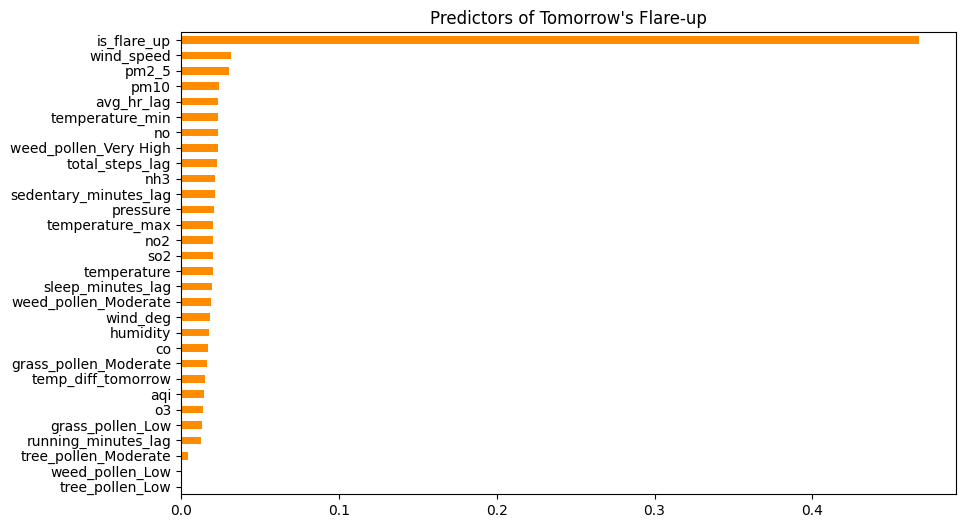

In [9]:
# Visualize Feature Importance
plt.figure(figsize=(10, 6))
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', color='darkorange')
plt.title("Predictors of Tomorrow's Flare-up")
plt.show()

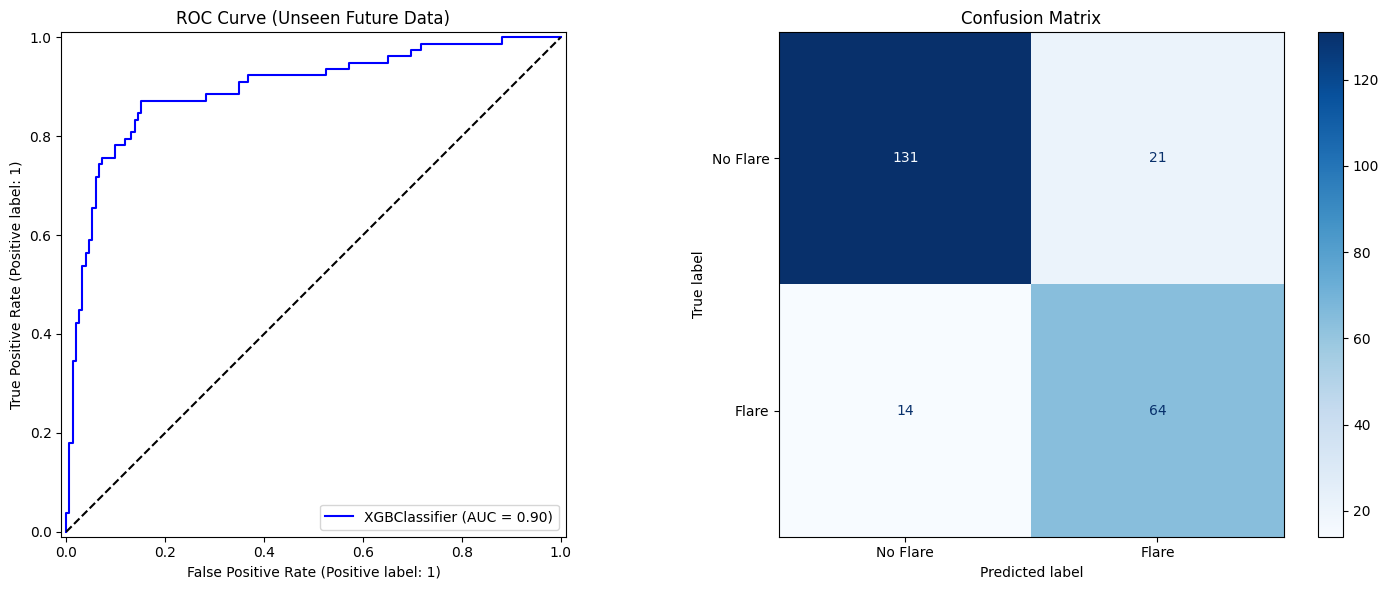

In [10]:
# Performance Visualization
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax[0], color='blue')
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_title("ROC Curve (Unseen Future Data)")

# Confusion Matrix
cm = confusion_matrix(y_test, model.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=['No Flare', 'Flare']).plot(cmap='Blues', ax=ax[1])
ax[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Personal Model Experiment

Skipping User 190: Insufficient data samples (134 total, 1.0 flares)
Skipping User 328: Insufficient data samples (7 total, 0.0 flares)
Skipping User 398: Insufficient data samples (23 total, 0.0 flares)
Skipping User 454: Insufficient data samples (7 total, 5.0 flares)
Skipping User 701: Insufficient data samples (85 total, 85.0 flares)
Skipping User 748: Insufficient data samples (1 total, 1.0 flares)
Skipping User 917: Insufficient data samples (6 total, 3.0 flares)

=== Personal Edge Model Evaluation Summary ===
Total Individual Models Trained and Saved: 11
Mean Personal AUC:      0.538
Median Personal AUC:    0.500
Mean Personal Recall:   0.350
Mean Personal Accuracy: 0.762


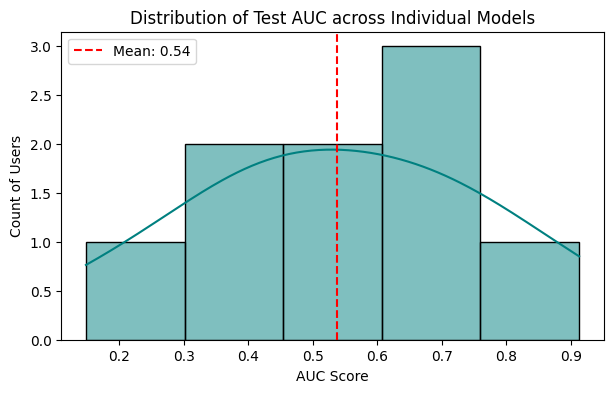

In [11]:
import os
import joblib
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    recall_score, accuracy_score, classification_report,
    roc_auc_score, roc_curve, confusion_matrix
)

# Create a local directory to save the individualized models for Edge AI deployment
models_dir = "./edge_personal_models"
os.makedirs(models_dir, exist_ok=True)

# Define explicit features and categorical columns for consistent dummy encoding
categorical_cols = ['grass_pollen', 'tree_pollen', 'weed_pollen']
valid_features = [c for c in X_cols if c not in ['actual_puffs', 'daily_night_symp', 'daily_day_symp', 'daily_limit_activity', 'is_flare_up']] + ['is_flare_up']
y_col = 'tomorrow_flare_up'

# Drop missing target rows and sort strictly by timeline
temporal_df = daily.dropna(subset=valid_features + [y_col]).sort_values(['user_key', 'date']).copy()

# Pre-encode categorical features globally to ensure consistent column structure across all edge models
X_all_encoded = pd.get_dummies(temporal_df[valid_features], columns=categorical_cols, drop_first=True)
encoded_feature_names = X_all_encoded.columns.tolist()

# Reattach user information and targets
processed_df = pd.concat([temporal_df[['user_key', y_col]], X_all_encoded], axis=1)

# Storage for aggregate individual performance metrics
individual_results = []

# Loop through each individual user independently
for user, user_df in processed_df.groupby('user_key'):
    n_samples = len(user_df)
    n_positives = user_df[y_col].sum()

    # Check minimum operational data limits for training an isolated time-series edge model
    if n_samples < 15 or n_positives < 2 or (n_samples - n_positives) < 2:
        print(f"Skipping User {user}: Insufficient data samples ({n_samples} total, {n_positives} flares)")
        continue

    # 1. Isolated Chronological Split (Last 20% of personal history is completely unseen)
    split_idx = int(n_samples * 0.8)
    user_train = user_df.iloc[:split_idx]
    user_test = user_df.iloc[split_idx:]

    X_train_u = user_train[encoded_feature_names]
    y_train_u = user_train[y_col].astype(int)
    X_test_u = user_test[encoded_feature_names]
    y_test_u = user_test[y_col].astype(int)

    # 2. Dynamic Scale Position Weighting to counter individual flare-up imbalance
    pos_weight = (len(y_train_u) - y_train_u.sum()) / max(1, y_train_u.sum())

    # 3. Instantiate and train a shallow, high-efficiency edge model
    # Keeping max_depth and n_estimators conservative makes the binary file highly optimized for Edge RAM footprint
    model_u = xgb.XGBClassifier(
        n_estimators=50,
        max_depth=3,
        scale_pos_weight=pos_weight,
        learning_rate=0.05,
        random_state=42,
        eval_metric='logloss'
    )
    model_u.fit(X_train_u, y_train_u)

    # 4. Save individual weights for export to device
    model_filename = os.path.join(models_dir, f"model_{user}.joblib")
    joblib.dump(model_u, model_filename)

    # 5. Personal Evaluation on Unseen Future Timeline
    probs_u = model_u.predict_proba(X_test_u)[:, 1]
    preds_u = model_u.predict(X_test_u)

    # Calculate personal metrics safely if test data has both classes present
    if len(np.unique(y_test_u)) > 1:
        auc_score = roc_auc_score(y_test_u, probs_u)
    else:
        auc_score = np.nan  # Cannot compute ROC AUC if test set has only zeros or only ones

    rec_score = recall_score(y_test_u, preds_u, zero_division=0)
    acc_score = accuracy_score(y_test_u, preds_u)

    individual_results.append({
        "user_key": user,
        "total_samples": n_samples,
        "test_samples": len(user_test),
        "test_auc": auc_score,
        "test_recall": rec_score,
        "test_accuracy": acc_score
    })

# Convert summary list into a DataFrame for analysis
results_df = pd.DataFrame(individual_results)

# 6. Global Performance Summary across all Personal Models
print("\n=== Personal Edge Model Evaluation Summary ===")
print(f"Total Individual Models Trained and Saved: {len(results_df)}")
print(f"Mean Personal AUC:      {results_df['test_auc'].dropna().mean():.3f}")
print(f"Median Personal AUC:    {results_df['test_auc'].dropna().median():.3f}")
print(f"Mean Personal Recall:   {results_df['test_recall'].mean():.3f}")
print(f"Mean Personal Accuracy: {results_df['test_accuracy'].mean():.3f}")

# Optional: Visualize the distribution of personal AUC metrics across users
if not results_df['test_auc'].dropna().empty:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=results_df, x='test_auc', kde=True, color='teal')
    plt.axvline(results_df['test_auc'].dropna().mean(), color='red', linestyle='--', label=f"Mean: {results_df['test_auc'].dropna().mean():.2f}")
    plt.title("Distribution of Test AUC across Individual Models")
    plt.xlabel("AUC Score")
    plt.ylabel("Count of Users")
    plt.legend()
    plt.show()

### Experiment: Global Model Pre-training + Individual Fine-tuning

This experiment tests the hypothesis that a global model, pre-trained on a larger population dataset, can provide a better starting point for individual personalization than training a model from scratch on limited individual data. We will iterate through each user:

1.  Train a global model *excluding* the current user.
2.  Fine-tune this global model using the current user's data.
3.  Evaluate the fine-tuned model's performance for that specific user.

Running Global + Personal Calibration Experiment

Users evaluated: 2

GLOBAL MODEL
AUC: 0.598
Precision: 0.562
Recall: 0.544
Accuracy: 0.780

GLOBAL + PERSONAL CALIBRATION
AUC: 0.604
Precision: 0.590
Recall: 0.548
Accuracy: 0.700


,user_key,n_samples,auc_global,auc_calibrated,precision_global,precision_calibrated,recall_global,recall_calibrated,accuracy_global,accuracy_calibrated
1,294,144,0.740741,0.730769,0.923077,0.846154,0.888889,0.846154,0.827586,0.733333
0,113,146,0.456000,0.477273,0.200000,0.333333,0.200000,0.250000,0.733333,0.666667


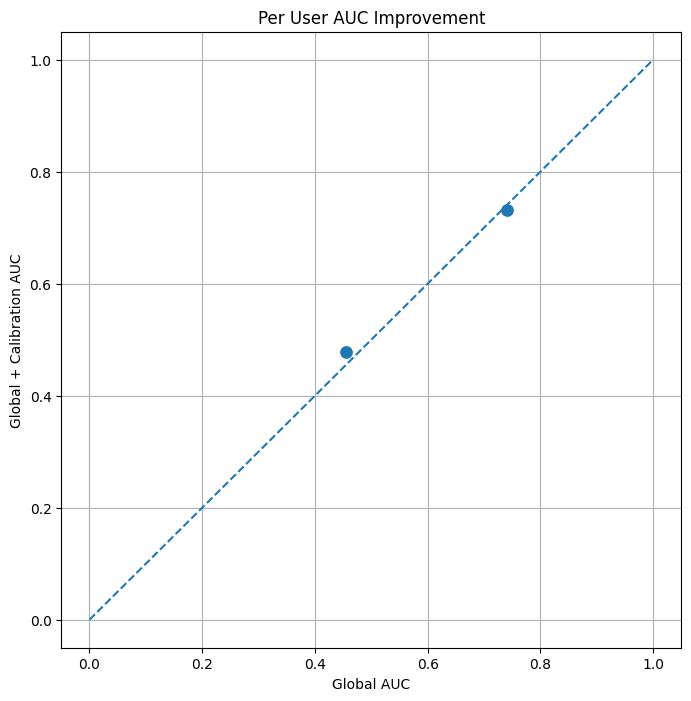

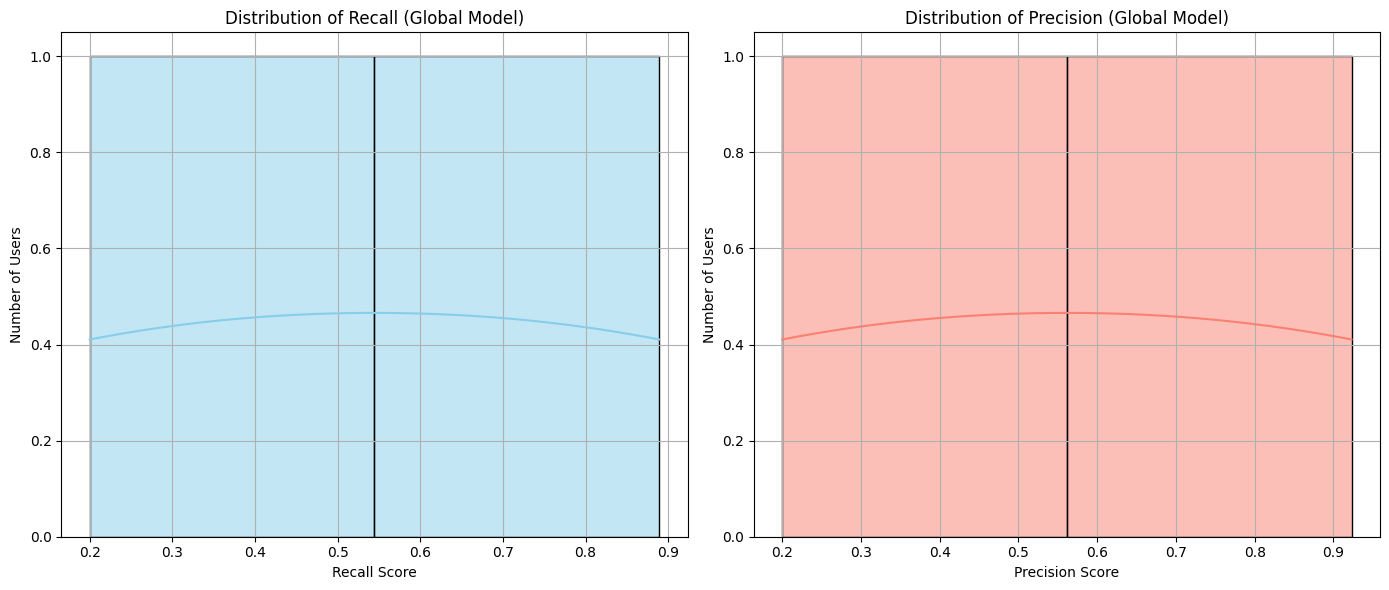

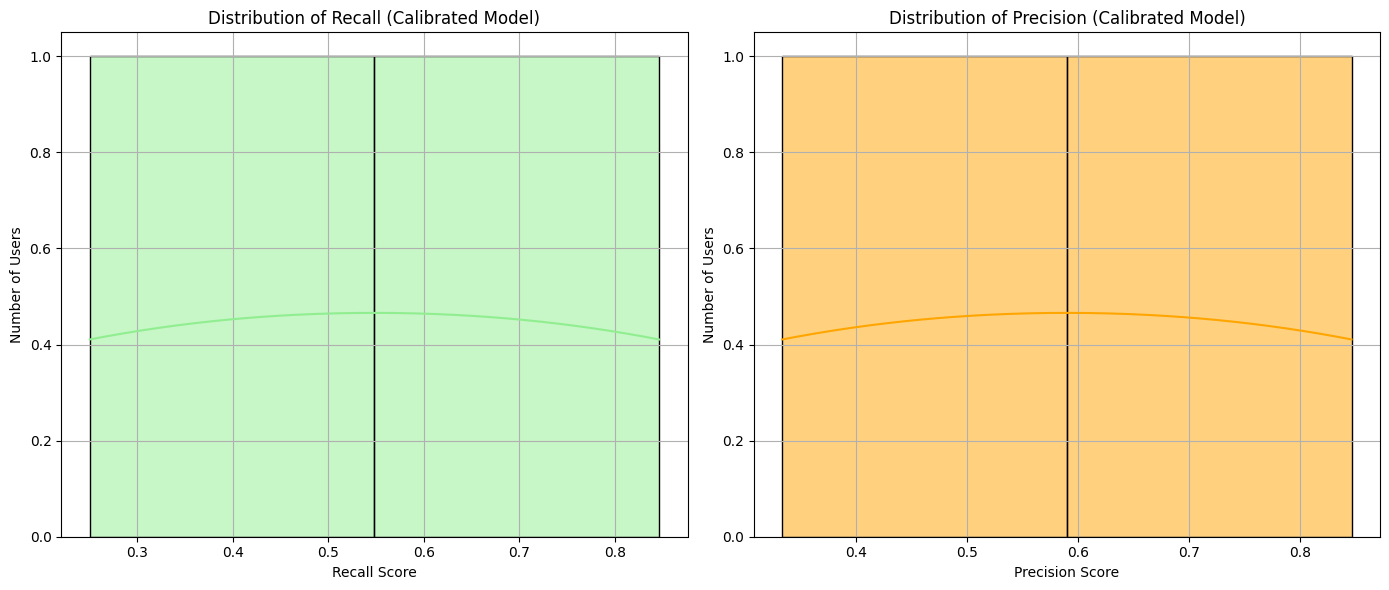


AUC Improvement


,user_key,n_samples,auc_global,auc_calibrated,auc_gain
0,113,146,0.456000,0.477273,0.021273
1,294,144,0.740741,0.730769,-0.009972


In [12]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    accuracy_score
)

# =====================================================
# SETTINGS
# =====================================================

valid_features = [
    c for c in X_cols
    if c not in [
        "actual_puffs",
        "daily_night_symp",
        "daily_day_symp",
        "daily_limit_activity",
        "is_flare_up",
    ]
] + ["is_flare_up"]

MIN_USER_ROWS = 100

# =====================================================
# DATA
# =====================================================

df = (
    daily
    .dropna(subset=valid_features + [y_col])
    .sort_values(["user_key", "date"])
    .copy()
)

results = []

print("Running Global + Personal Calibration Experiment")

# =====================================================
# LOOP OVER USERS
# =====================================================

for user in df["user_key"].unique():

    user_df = df[df["user_key"] == user].copy()

    if len(user_df) < MIN_USER_ROWS:
        continue

    # ---------------------------
    # GLOBAL TRAINING DATA
    # ---------------------------

    global_train = df[df["user_key"] != user].copy()

    X_global = pd.get_dummies(
        global_train[valid_features],
        columns=categorical_cols,
        drop_first=True,
    )

    y_global = global_train[y_col].astype(int)

    # ---------------------------
    # USER DATA
    # ---------------------------

    split_idx = int(len(user_df) * 0.8)

    user_train = user_df.iloc[:split_idx]
    user_test = user_df.iloc[split_idx:]

    if len(user_test) < 20:
        continue

    X_test = pd.get_dummies(
        user_test[valid_features],
        columns=categorical_cols,
        drop_first=True,
    )

    X_test = X_test.reindex(
        columns=X_global.columns,
        fill_value=0,
    )

    y_test = user_test[y_col].astype(int)

    # need both classes in test set
    if y_test.nunique() < 2:
        continue

    # ---------------------------
    # GLOBAL MODEL
    # ---------------------------

    pos_weight = (
        (len(y_global) - y_global.sum())
        / max(1, y_global.sum())
    )

    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=pos_weight,
        random_state=42,
    )

    model.fit(X_global, y_global)

    probs_global = model.predict_proba(X_test)[:, 1]

    preds_global = (probs_global >= 0.5).astype(int)

    # ---------------------------
    # GLOBAL METRICS
    # ---------------------------

    auc_global = roc_auc_score(y_test, probs_global)

    precision_global = precision_score(
        y_test,
        preds_global,
        zero_division=0,
    )

    recall_global = recall_score(
        y_test,
        preds_global,
        zero_division=0,
    )

    acc_global = accuracy_score(
        y_test,
        preds_global,
    )

    # =====================================================
    # PERSONAL CALIBRATION
    # =====================================================

    calibration_size = len(y_test) // 2

    y_cal = y_test.iloc[:calibration_size]
    p_cal = probs_global[:calibration_size]

    user_bias = (
        y_cal.mean()
        - p_cal.mean()
    )

    probs_calibrated = np.clip(
        probs_global[calibration_size:] + user_bias,
        0,
        1,
    )

    y_eval = y_test.iloc[calibration_size:]

    if len(np.unique(y_eval)) < 2:
        continue

    preds_calibrated = (
        probs_calibrated >= 0.5
    ).astype(int)

    auc_cal = roc_auc_score(
        y_eval,
        probs_calibrated,
    )

    precision_cal = precision_score(
        y_eval,
        preds_calibrated,
        zero_division=0,
    )

    recall_cal = recall_score(
        y_eval,
        preds_calibrated,
        zero_division=0,
    )

    acc_cal = accuracy_score(
        y_eval,
        preds_calibrated,
    )

    results.append({
        "user_key": user,
        "n_samples": len(user_df),

        "auc_global": auc_global,
        "auc_calibrated": auc_cal,

        "precision_global": precision_global,
        "precision_calibrated": precision_cal,

        "recall_global": recall_global,
        "recall_calibrated": recall_cal,

        "accuracy_global": acc_global,
        "accuracy_calibrated": acc_cal,
    })

# =====================================================
# RESULTS TABLE
# =====================================================

results_df = pd.DataFrame(results)

print("\nUsers evaluated:", len(results_df))

print("\nGLOBAL MODEL")
print(
    f"AUC: {results_df['auc_global'].mean():.3f}"
)
print(
    f"Precision: {results_df['precision_global'].mean():.3f}"
)
print(
    f"Recall: {results_df['recall_global'].mean():.3f}"
)
print(
    f"Accuracy: {results_df['accuracy_global'].mean():.3f}"
)

print("\nGLOBAL + PERSONAL CALIBRATION")
print(
    f"AUC: {results_df['auc_calibrated'].mean():.3f}"
)
print(
    f"Precision: {results_df['precision_calibrated'].mean():.3f}"
)
print(
    f"Recall: {results_df['recall_calibrated'].mean():.3f}"
)
print(
    f"Accuracy: {results_df['accuracy_calibrated'].mean():.3f}"
)

display(
    results_df.sort_values(
        "auc_calibrated",
        ascending=False,
    )
)

# =====================================================
# SCATTER PLOT
# =====================================================

plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=results_df,
    x="auc_global",
    y="auc_calibrated",
    s=100,
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

plt.xlabel("Global AUC")
plt.ylabel("Global + Calibration AUC")

plt.title(
    "Per User AUC Improvement"
)

plt.grid(True)
plt.show()

# =====================================================
# DISTRIBUTION PLOTS FOR GLOBAL MODEL METRICS
# =====================================================

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(results_df['recall_global'].dropna(), kde=True, color='skyblue')
plt.title('Distribution of Recall (Global Model)')
plt.xlabel('Recall Score')
plt.ylabel('Number of Users')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.histplot(results_df['precision_global'].dropna(), kde=True, color='salmon')
plt.title('Distribution of Precision (Global Model)')
plt.xlabel('Precision Score')
plt.ylabel('Number of Users')
plt.grid(True)

plt.tight_layout()
plt.show()

# =====================================================
# DISTRIBUTION PLOTS FOR CALIBRATED MODEL METRICS
# =====================================================

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(results_df['recall_calibrated'].dropna(), kde=True, color='lightgreen')
plt.title('Distribution of Recall (Calibrated Model)')
plt.xlabel('Recall Score')
plt.ylabel('Number of Users')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.histplot(results_df['precision_calibrated'].dropna(), kde=True, color='orange')
plt.title('Distribution of Precision (Calibrated Model)')
plt.xlabel('Precision Score')
plt.ylabel('Number of Users')
plt.grid(True)

plt.tight_layout()
plt.show()

# =====================================================
# IMPROVEMENT TABLE
# =====================================================

results_df["auc_gain"] = (
    results_df["auc_calibrated"]
    - results_df["auc_global"]
)

print("\nAUC Improvement")

display(
    results_df[
        [
            "user_key",
            "n_samples",
            "auc_global",
            "auc_calibrated",
            "auc_gain",
        ]
    ].sort_values(
        "auc_gain",
        ascending=False,
    )
)